# RAG Fallback — Algorithm Benchmark

Comparative study of keyword-based fallback search algorithms for the RAG module.  
All experiments use the **self-retrieval benchmark**: each chunk's top terms are used as
the search query, and we measure whether the source chunk appears in the results.

**Algorithms under test:**

| Name | Description |
|---|---|
| Baseline (current) | Custom term-overlap scorer with phrase and bigram bonuses |
| BM25Okapi | Probabilistic BM25: TF saturation + IDF weighting |
| BM25L | BM25 variant with softer TF ceiling — better for unequal-length docs |
| BM25+Morph | BM25Okapi + pymorphy3 Russian lemmatisation |

**Experiments:**
1. Algorithm comparison at default settings  
2. Hit@K curves — coverage vs retrieval depth  
3. Stability across random seeds  
4. Sample size sensitivity  
5. Speed vs quality trade-off  

**Known limitation of self-retrieval:** synthetic queries come from the same word forms
as the chunk text, so BM25+Morph's morphological advantage is underestimated here.
Real student queries use genitive, dative, plural, etc. — the gap grows in production.

In [1]:
# Install optional dependencies if missing
import importlib, subprocess, sys

def _ensure(pkg, import_name=None):
    mod = import_name or pkg.replace('-', '_')
    if importlib.util.find_spec(mod) is None:
        print(f'Installing {pkg} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'{pkg}: installed')
    else:
        print(f'{pkg}: OK')

_ensure('rank-bm25', 'rank_bm25')
_ensure('pymorphy3')
_ensure('seaborn')
_ensure('pandas')

rank-bm25: OK
pymorphy3: OK
seaborn: OK
pandas: OK


In [2]:
import os, random, sys, time, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# Make sure the project root is importable
project_root = Path('.').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from benchmark_fallback import (
    load_chunks,
    BaselineSearcher,
    BM25OkapiSearcher,
    BM25LSearcher,
    BM25MorphSearcher,
    _evaluate,
    _generate_query,
    HAS_BM25,
    HAS_PYMORPHY,
)

# ── Global plot style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 12,
})

COLORS = {
    'Baseline (current)': '#6c757d',
    'BM25Okapi':          '#2196F3',
    'BM25L':              '#FF9800',
    'BM25+Morph':         '#4CAF50',
}
FALLBACK_COLORS = ['#6c757d', '#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

print('Imports OK.  HAS_BM25={},  HAS_PYMORPHY={}'.format(HAS_BM25, HAS_PYMORPHY))

Imports OK.  HAS_BM25=True,  HAS_PYMORPHY=True


## ⚙️ Configuration

Change `DISCIPLINE` to match a folder slug inside your `data/disciplines/` directory.  
Set `SKIP_MORPH = True` to skip the BM25+Morph model (lemmatisation can take ~1 min on large corpora).  
All experiments below reuse the searchers built in the next cell — **run it once**.

In [3]:
DISCIPLINE   = 'math'   # ← your discipline slug
SAMPLE_SIZE  = 150      # default sample for experiments 1, 2, 5
DEFAULT_SEED = 42
DEFAULT_TOPK = 10
SKIP_MORPH   = False    # True → skip BM25+Morph to save time

from dotenv import load_dotenv
load_dotenv()
DISCIPLINES_DIR = os.getenv('DISCIPLINES_DIR', 'data/disciplines')

# ── Load corpus ────────────────────────────────────────────────────────────────
print('Loading corpus: discipline={!r}, dir={!r}'.format(DISCIPLINE, DISCIPLINES_DIR))
chunks = load_chunks(DISCIPLINES_DIR, DISCIPLINE)
assert chunks, 'No chunks found! Check DISCIPLINES_DIR in .env and that PDFs exist.'

sources = {src for src, _ in chunks}
print('Chunks: {}  |  PDFs: {}'.format(len(chunks), len(sources)))
print()

# ── Build searchers ────────────────────────────────────────────────────────────
# Build once, reuse across ALL experiments
searchers = []

print('Building Baseline ...')
searchers.append(BaselineSearcher(chunks))

if HAS_BM25:
    print('Building BM25Okapi ...')
    searchers.append(BM25OkapiSearcher(chunks))
    print('Building BM25L ...')
    searchers.append(BM25LSearcher(chunks))
    if HAS_PYMORPHY and not SKIP_MORPH:
        print('Building BM25+Morph (may take ~1 min) ...')
        searchers.append(BM25MorphSearcher(chunks))
    elif SKIP_MORPH:
        print('  BM25+Morph skipped (SKIP_MORPH=True)')
    else:
        print('  pymorphy3 not found — skip BM25+Morph.  Run: pip install pymorphy3')
else:
    print('  rank-bm25 not found — only Baseline.  Run: pip install rank-bm25')

ALGO_NAMES  = [s.name for s in searchers]
ALGO_COLORS = [COLORS.get(n, FALLBACK_COLORS[i]) for i, n in enumerate(ALGO_NAMES)]
METRIC_COLS = ['Hit@1', 'Hit@3', 'Hit@5', 'Hit@{}'.format(DEFAULT_TOPK), 'MRR']

print()
print('Algorithms ready:', ALGO_NAMES)

Loading corpus: discipline='math', dir='data/disciplines'
Chunks: 539  |  PDFs: 2

Building Baseline ...
Building BM25Okapi ...
Building BM25L ...
Building BM25+Morph (may take ~1 min) ...
    Lemmatizing corpus... done

Algorithms ready: ['Baseline (current)', 'BM25Okapi', 'BM25L', 'BM25+Morph']


## Experiment 1 — Algorithm Comparison

Single run with default settings. Results shown as a **grouped bar chart** and a **heatmap** (raw + normalised).

In [4]:
def run_single(seed, sample_size, top_k, searcher_list=None):
    '''Run all searchers on one random sample. Returns a DataFrame indexed by algorithm name.'''
    if searcher_list is None:
        searcher_list = searchers
    random.seed(seed)
    texts = [t for _, t in random.sample(chunks, min(sample_size, len(chunks)))]
    rows = []
    for s in searcher_list:
        t0  = time.perf_counter()
        m   = _evaluate(s, texts, top_k)
        ela = time.perf_counter() - t0
        m['Time_s']    = ela
        m['Algorithm'] = s.name
        rows.append(m)
    df = pd.DataFrame(rows).set_index('Algorithm')
    return df.drop(columns=['n'], errors='ignore')


df_main = run_single(DEFAULT_SEED, SAMPLE_SIZE, DEFAULT_TOPK)
display(df_main[METRIC_COLS + ['Time_s']].round(4))

,Hit@1,Hit@3,Hit@5,Hit@10,MRR,Time_s
Algorithm,,,,,,
Baseline (current),0.3200,0.4600,0.4933,0.5333,0.4020,3.3765
BM25Okapi,0.9133,1.0000,1.0000,1.0000,0.9544,0.0607
BM25L,0.6800,0.8800,0.9267,0.9667,0.7909,0.0634
BM25+Morph,0.7933,0.9333,0.9467,0.9733,0.8641,0.0992


In [ ]:
# ── Grouped bar chart ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(len(METRIC_COLS))
n_algos = len(df_main)
width   = 0.8 / n_algos

for i, (algo, row) in enumerate(df_main.iterrows()):
    offset = (i - n_algos / 2 + 0.5) * width
    vals   = [row[m] for m in METRIC_COLS]
    bars   = ax.bar(x + offset, vals, width * 0.9,
                    color=COLORS.get(algo, FALLBACK_COLORS[i]),
                    label=algo, alpha=0.9)
    for bar, val in zip(bars, vals):
        if val > 0.02:
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.007,
                    '{:.2f}'.format(val), ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(METRIC_COLS, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Algorithm comparison — {} | samples={}, seed={}, top_k={}'.format(
    DISCIPLINE, SAMPLE_SIZE, DEFAULT_SEED, DEFAULT_TOPK))
ax.legend(loc='upper right', framealpha=0.9)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('benchmark_01_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Heatmap: raw scores + normalised ──────────────────────────────────────────
score_df = df_main[METRIC_COLS].copy()

normed = score_df.copy()
for col in METRIC_COLS:
    rng = normed[col].max() - normed[col].min()
    normed[col] = (normed[col] - normed[col].min()) / rng if rng > 1e-9 else 0.5

n_rows = max(3, len(df_main) * 0.8 + 1.5)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, n_rows))

sns.heatmap(score_df, annot=True, fmt='.3f', cmap='YlGn',
            ax=ax1, linewidths=0.5, cbar_kws={'label': 'Score'})
ax1.set_title('Raw scores')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=25, ha='right')

sns.heatmap(normed, annot=True, fmt='.2f', cmap='YlGn',
            ax=ax2, linewidths=0.5,
            cbar_kws={'label': '0 = worst, 1 = best (per metric)'})
ax2.set_title('Normalised (per-metric min-max)')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=25, ha='right')

plt.suptitle('Performance heatmap — ' + DISCIPLINE, y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('benchmark_02_heatmap.png', bbox_inches='tight')
plt.show()

## Experiment 2 — Hit@K Curves

How fast does coverage grow as retrieval depth increases?  
Each curve shows Hit@k for k from 1 to 15.  
A **steeper rise** and **higher plateau** = better algorithm.  
Read off the minimum k required to achieve a target Hit rate (e.g. 0.8).

In [ ]:
MAX_K = 15

def hitk_curve(s, texts, max_k=MAX_K):
    '''Compute Hit@k for every k in 1..max_k. Returns a list of length max_k.'''
    ranks = []
    for chunk_text in texts:
        q = _generate_query(chunk_text)
        if not q:
            continue
        results = s.search(q, top_k=max_k)
        rank = next(
            (i for i, r in enumerate(results, 1) if r.strip() == chunk_text.strip()),
            None,
        )
        ranks.append(rank)
    n = len(ranks)
    return [sum(1 for r in ranks if r is not None and r <= k) / n
            for k in range(1, max_k + 1)]


random.seed(DEFAULT_SEED)
texts_hitk = [t for _, t in random.sample(chunks, min(SAMPLE_SIZE, len(chunks)))]

curves = {}
for s in searchers:
    curves[s.name] = hitk_curve(s, texts_hitk)
    print('  {} → Hit@{} = {:.3f}'.format(s.name, MAX_K, curves[s.name][-1]))

ks = list(range(1, MAX_K + 1))

fig, ax = plt.subplots(figsize=(10, 5))
for algo, curve in curves.items():
    ax.plot(ks, curve, marker='o', ms=5, lw=2,
            color=COLORS.get(algo), label=algo)

ax.axhline(0.8, ls='--', lw=1, color='grey', alpha=0.6, label='Hit = 0.80 target')
ax.set_xlabel('k  (retrieval depth)')
ax.set_ylabel('Hit@k')
ax.set_title('Hit@K curves — {} | samples={}, seed={}'.format(
    DISCIPLINE, SAMPLE_SIZE, DEFAULT_SEED))
ax.set_xticks(ks)
ax.legend(framealpha=0.9)
ax.yaxis.grid(True, alpha=0.4)
ax.set_ylim(0, 1.05)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('benchmark_03_hitk_curves.png', bbox_inches='tight')
plt.show()

## Experiment 3 — Stability Across Random Seeds

Does algorithm ranking stay consistent when the sample changes?  
We repeat evaluation with 10 different seeds and plot the MRR distribution.  
- **Narrow box** → stable estimate; you can trust results from a small sample  
- **Wide box** → sensitive to which chunks are sampled; run more samples

In [ ]:
SEEDS = [0, 7, 42, 99, 137, 256, 314, 512, 777, 1024]

stability = {n: [] for n in ALGO_NAMES}
for seed in SEEDS:
    df_s = run_single(seed, SAMPLE_SIZE, DEFAULT_TOPK)
    for algo in ALGO_NAMES:
        stability[algo].append(df_s.loc[algo, 'MRR'])
    print('  seed={} done'.format(seed))

stab_df = pd.DataFrame(stability, index=SEEDS)
stab_df.index.name = 'seed'

print('\nMRR across {} seeds:'.format(len(SEEDS)))
display(stab_df.agg(['mean', 'std']).round(4))

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Box plot ───────────────────────────────────────────────────────────────────
bp = ax1.boxplot([stab_df[n].values for n in ALGO_NAMES],
                 patch_artist=True, widths=0.5, notch=False)
for patch, color in zip(bp['boxes'], ALGO_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax1.set_xticks(range(1, len(ALGO_NAMES) + 1))
ax1.set_xticklabels(ALGO_NAMES, rotation=15, ha='right')
ax1.set_ylabel('MRR')
ax1.set_title('MRR distribution — {} seeds'.format(len(SEEDS)))
ax1.yaxis.grid(True, alpha=0.4)
ax1.set_axisbelow(True)

# ── Mean ± std bar chart ───────────────────────────────────────────────────────
means = stab_df.mean()
stds  = stab_df.std()
bars  = ax2.bar(ALGO_NAMES, means, yerr=stds, capsize=5,
                color=ALGO_COLORS, alpha=0.85, width=0.5)
ax2.set_ylim(0, 1.05)
ax2.set_ylabel('MRR  (mean \u00b1 std)')
ax2.set_title('Mean MRR with standard deviation')
ax2.set_xticklabels(ALGO_NAMES, rotation=15, ha='right')
for bar, m_val, s_val in zip(bars, means.values, stds.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, m_val + s_val + 0.012,
             '{:.3f}'.format(m_val), ha='center', va='bottom', fontsize=9)
ax2.yaxis.grid(True, alpha=0.4)
ax2.set_axisbelow(True)

plt.suptitle('Stability analysis — ' + DISCIPLINE, fontsize=13)
plt.tight_layout()
plt.savefig('benchmark_04_stability.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── MRR per seed: line chart (shows if any seed is an outlier) ─────────────────
fig, ax = plt.subplots(figsize=(11, 4))
for algo in ALGO_NAMES:
    ax.plot(SEEDS, stab_df[algo].values, marker='o', ms=5, lw=1.5,
            color=COLORS.get(algo), label=algo, alpha=0.85)

ax.set_xlabel('Random seed')
ax.set_ylabel('MRR')
ax.set_title('MRR per seed — {} | samples={}, top_k={}'.format(
    DISCIPLINE, SAMPLE_SIZE, DEFAULT_TOPK))
ax.set_xticks(SEEDS)
ax.legend(framealpha=0.9, ncol=2)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('benchmark_04b_mrr_per_seed.png', bbox_inches='tight')
plt.show()

## Experiment 4 — Sample Size Sensitivity

How many evaluation samples are needed for a reliable score?  
If MRR stabilises at small n → a cheaper benchmark is sufficient.  
If MRR keeps drifting at large n → results from small samples are unreliable.

In [ ]:
SAMPLE_SIZES = [30, 60, 100, 150, 200, 300, 500]
SAMPLE_SIZES = [n for n in SAMPLE_SIZES if n <= len(chunks)]

ss_mrr   = {algo: [] for algo in ALGO_NAMES}
ss_hit5  = {algo: [] for algo in ALGO_NAMES}

for n in SAMPLE_SIZES:
    df_n = run_single(DEFAULT_SEED, n, DEFAULT_TOPK)
    for algo in ALGO_NAMES:
        ss_mrr[algo].append(df_n.loc[algo, 'MRR'])
        ss_hit5[algo].append(df_n.loc[algo, 'Hit@5'])
    print('  sample_size={} done'.format(n))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for algo in ALGO_NAMES:
    ax1.plot(SAMPLE_SIZES, ss_mrr[algo], marker='o', ms=6, lw=2,
             color=COLORS.get(algo), label=algo)
    ax2.plot(SAMPLE_SIZES, ss_hit5[algo], marker='s', ms=6, lw=2,
             color=COLORS.get(algo), label=algo)

for ax, metric in [(ax1, 'MRR'), (ax2, 'Hit@5')]:
    ax.set_xlabel('Sample size')
    ax.set_ylabel(metric)
    ax.set_title('{} vs sample size — {} | seed={}'.format(metric, DISCIPLINE, DEFAULT_SEED))
    ax.set_xticks(SAMPLE_SIZES)
    ax.legend(framealpha=0.9)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('benchmark_05_sample_size.png', bbox_inches='tight')
plt.show()

## Experiment 5 — Speed vs Quality Trade-off

Each point = one algorithm.  
- **x-axis** — evaluation time (proxy for production search latency)  
- **y-axis** — MRR  
- **bubble size** — Hit@5  

The **ideal** algorithm sits in the **top-left corner** (fast + accurate).  
Algorithms in the lower-right have high cost without quality gain.

In [ ]:
times  = df_main['Time_s'].values
mrrs   = df_main['MRR'].values
hit5s  = df_main['Hit@5'].values
algos  = list(df_main.index)

fig, ax = plt.subplots(figsize=(9, 5))
for algo, t, mrr, h5 in zip(algos, times, mrrs, hit5s):
    ax.scatter(t, mrr, s=h5 * 1200 + 80, alpha=0.85,
               color=COLORS.get(algo), zorder=3, edgecolors='white', lw=1.5)
    ax.annotate(algo, (t, mrr),
                xytext=(8, 4), textcoords='offset points', fontsize=9)

# Bubble size legend
for h5_ref in [0.3, 0.6, 0.9]:
    ax.scatter([], [], s=h5_ref * 1200 + 80, c='grey', alpha=0.5,
               label='Hit@5 = {:.1f}'.format(h5_ref))

ax.set_xlabel('Evaluation time (seconds for {} samples)'.format(SAMPLE_SIZE))
ax.set_ylabel('MRR')
ax.set_title('Speed vs Quality — bubble = Hit@5\n{} | samples={}'.format(DISCIPLINE, SAMPLE_SIZE))
ax.legend(title='Bubble size', framealpha=0.9, loc='lower right')
ax.yaxis.grid(True, alpha=0.4)
ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('benchmark_06_speed_vs_quality.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Metric gain vs Baseline (delta table) ─────────────────────────────────────
baseline_row = df_main.loc['Baseline (current)', METRIC_COLS]
delta = df_main[METRIC_COLS].subtract(baseline_row)
delta.columns = ['+\u0394 ' + c for c in METRIC_COLS]

print('Gain relative to Baseline (positive = better):')
display(delta.drop(index='Baseline (current)', errors='ignore').round(4)
        .style.background_gradient(cmap='RdYlGn', axis=None))

## Experiment 6 — LLM-as-Judge Evaluation

Self-retrieval metrics (Hit@k, MRR) measure whether the *source chunk* reappears in results —
a useful **proxy**, but it does not tell you whether the retrieved context is genuinely helpful.

LLM-as-Judge asks a language model to rate each retrieved chunk on a 0–3 relevance scale
and whether the whole context is *sufficient* to answer the question.

| Metric | What it measures |
|---|---|
| **LLM-Precision\@k** | Fraction of top-k chunks with grade ≥ 2 (useful) |
| **LLM-NDCG\@k** | Rank-weighted relevance — high grade in position 1 > position 5 |
| **LLM-MRR** | Reciprocal rank of the first genuinely useful chunk |
| **LLM-Sufficiency** | Does the whole retrieved context answer the question? (0–1) |

> **Cost:** each query = 1 batch chunk-rating call + 1 sufficiency call.  
> `JUDGE_SAMPLES=20` × 4 algorithms → ~160 calls ≈ **\$0.003** at Gemini Flash rates.  
> All responses cached in `judge_cache.json` — reruns cost nothing.

In [5]:
# ── LLM Judge setup ──────────────────────────────────────────────────────
from statistics import mean as _smean

try:
    from llm_judge import LLMJudge, ndcg as _ndcg
    HAS_JUDGE = True
except ImportError:
    HAS_JUDGE = False
    print('⚠  llm_judge.py not found — place it next to this notebook.')

JUDGE_SAMPLES = 20   # small: each sample → 2 API calls per searcher
JUDGE_TOPK    = DEFAULT_TOPK

if HAS_JUDGE:
    judge = LLMJudge.from_env(cache_path='judge_cache.json')
    print(f'Judge: {judge}')

    random.seed(DEFAULT_SEED)
    judge_texts = [t for _, t in random.sample(chunks, min(JUDGE_SAMPLES, len(chunks)))]
    print(f'Sample: {len(judge_texts)} chunks  |  top-k={JUDGE_TOPK}')
    print(f'Cache: {judge.cache_size} entries (0 = first run, hits cache on reruns)')
    print()

    # ── Evaluation loop ────────────────────────────────────────────────────
    judge_results    = {}
    judge_grade_dist = {}   # algo -> [frac_0, frac_1, frac_2, frac_3]

    for _s in searchers:
        print(f'  Judging {_s.name} ...', end=' ', flush=True)
        _grades_all, _suff_all = [], []

        for _txt in judge_texts:
            _q = _generate_query(_txt)
            if not _q:
                continue
            _res = _s.search(_q, top_k=JUDGE_TOPK)
            if not _res:
                continue
            _grades_all.append(judge.rate_chunks(_q, _res))
            _suff_all.append(judge.rate_sufficiency(_q, _res))

        if _grades_all:
            _prec  = _smean(sum(g >= 2 for g in gs) / len(gs) for gs in _grades_all)
            _ndcgv = _smean(_ndcg(gs) for gs in _grades_all)
            _mrr   = _smean(
                next((1/(i+1) for i, g in enumerate(gs) if g >= 2), 0.0)
                for gs in _grades_all
            )
            _suff  = _smean(sv / 2 for sv in _suff_all) if _suff_all else 0.0
            _counts = [0, 0, 0, 0]
            _tot    = 0
            for gs in _grades_all:
                for g in gs:
                    _counts[g] += 1
                    _tot += 1
            judge_grade_dist[_s.name] = [c / _tot if _tot else 0 for c in _counts]
        else:
            _prec = _ndcgv = _mrr = _suff = 0.0
            judge_grade_dist[_s.name] = [0.0] * 4

        judge_results[_s.name] = {
            'LLM-Prec@k': _prec, 'LLM-NDCG@k': _ndcgv,
            'LLM-MRR': _mrr, 'LLM-Sufficiency': _suff,
            'n': len(_grades_all),
        }
        print(f'done  (n={len(_grades_all)}, cache={judge.cache_size} entries)')

    df_judge = pd.DataFrame(judge_results).T
    df_judge.index.name = 'Algorithm'
    display(df_judge.round(3))
else:
    print('⚠  Skipping — set LLM_PROVIDER + OPENROUTER_API_KEY in .env')
    df_judge = None
    judge_grade_dist = {}

Judge: LLMJudge(provider='openrouter#ollama', model='google/gemini-2.5-flash', cache=240 entries)
Sample: 20 chunks  |  top-k=10
Cache: 240 entries (0 = first run, hits cache on reruns)

  Judging Baseline (current) ... done  (n=20, cache=280 entries)
  Judging BM25Okapi ... done  (n=20, cache=320 entries)
  Judging BM25L ... done  (n=20, cache=360 entries)
  Judging BM25+Morph ... done  (n=20, cache=400 entries)


,LLM-Prec@k,LLM-NDCG@k,LLM-MRR,LLM-Sufficiency,n
Algorithm,,,,,
Baseline (current),0.570,0.912,0.975,0.500,20.0
BM25Okapi,0.565,0.924,0.962,0.575,20.0
BM25L,0.555,0.908,0.958,0.450,20.0
BM25+Morph,0.635,0.955,1.000,0.575,20.0


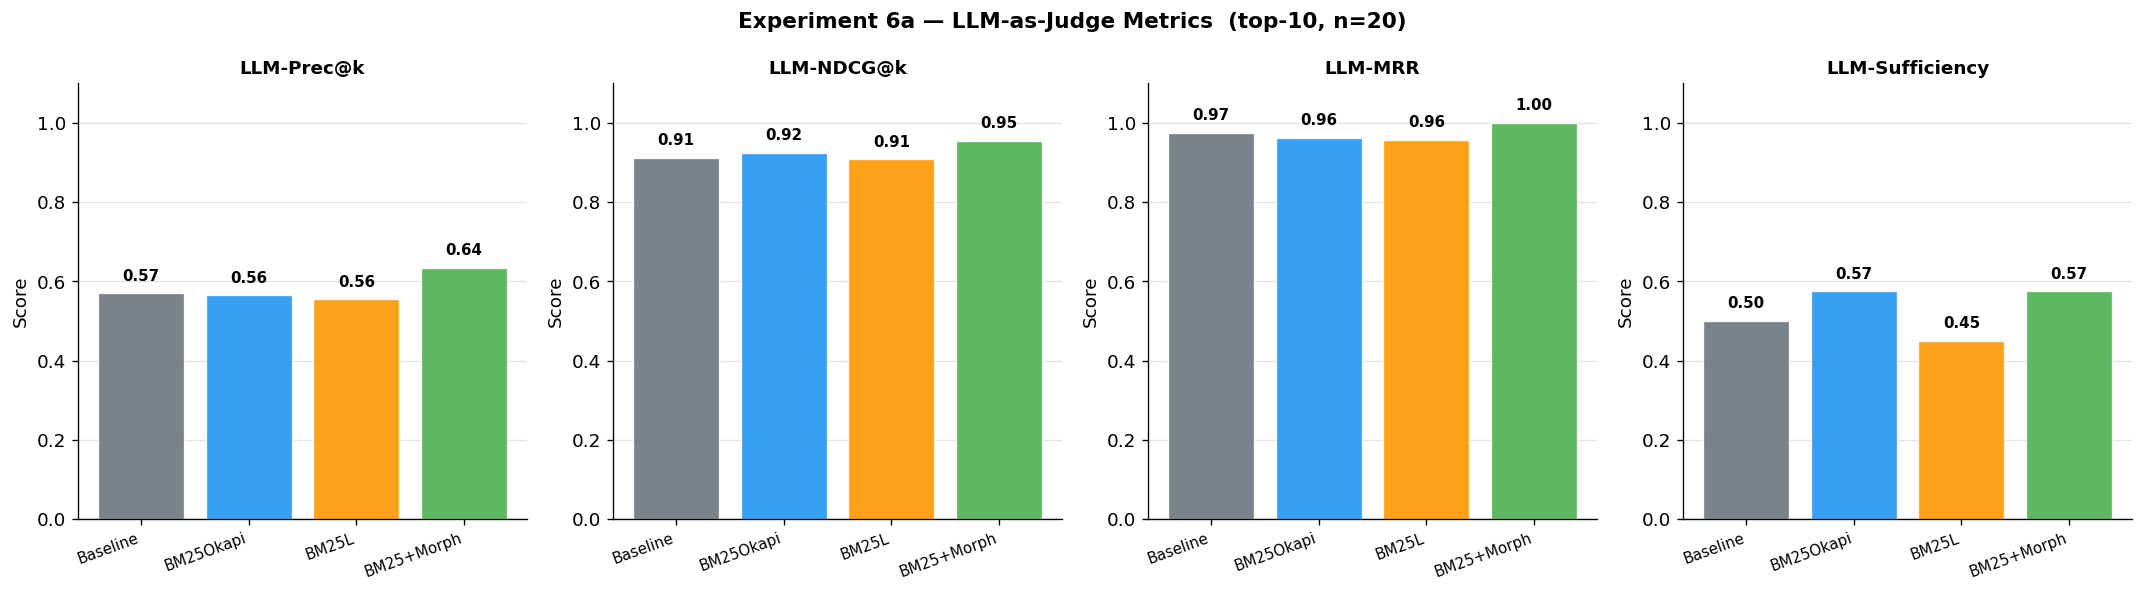

Saved: benchmark_07_llm_metrics.png


In [6]:
if HAS_JUDGE and df_judge is not None:
    _llm_metrics = ['LLM-Prec@k', 'LLM-NDCG@k', 'LLM-MRR', 'LLM-Sufficiency']
    _present = [n for n in ALGO_NAMES if n in df_judge.index]

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle(
        f'Experiment 6a — LLM-as-Judge Metrics  '
        f'(top-{JUDGE_TOPK}, n={len(judge_texts)})',
        fontsize=13, fontweight='bold'
    )

    for ax, metric in zip(axes, _llm_metrics):
        vals   = [df_judge.loc[n, metric] for n in _present]
        _clrs  = [COLORS.get(n, '#888') for n in _present]
        labels = [n.replace(' (current)', '') for n in _present]
        bars   = ax.bar(range(len(_present)), vals, color=_clrs,
                        edgecolor='white', linewidth=0.8, alpha=0.9)
        ax.set_xticks(range(len(_present)))
        ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
        ax.set_ylim(0, 1.1)
        ax.set_title(metric, fontweight='bold', fontsize=11)
        ax.set_ylabel('Score')
        ax.yaxis.grid(True, alpha=0.35)
        ax.set_axisbelow(True)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.025,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig('benchmark_07_llm_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: benchmark_07_llm_metrics.png')

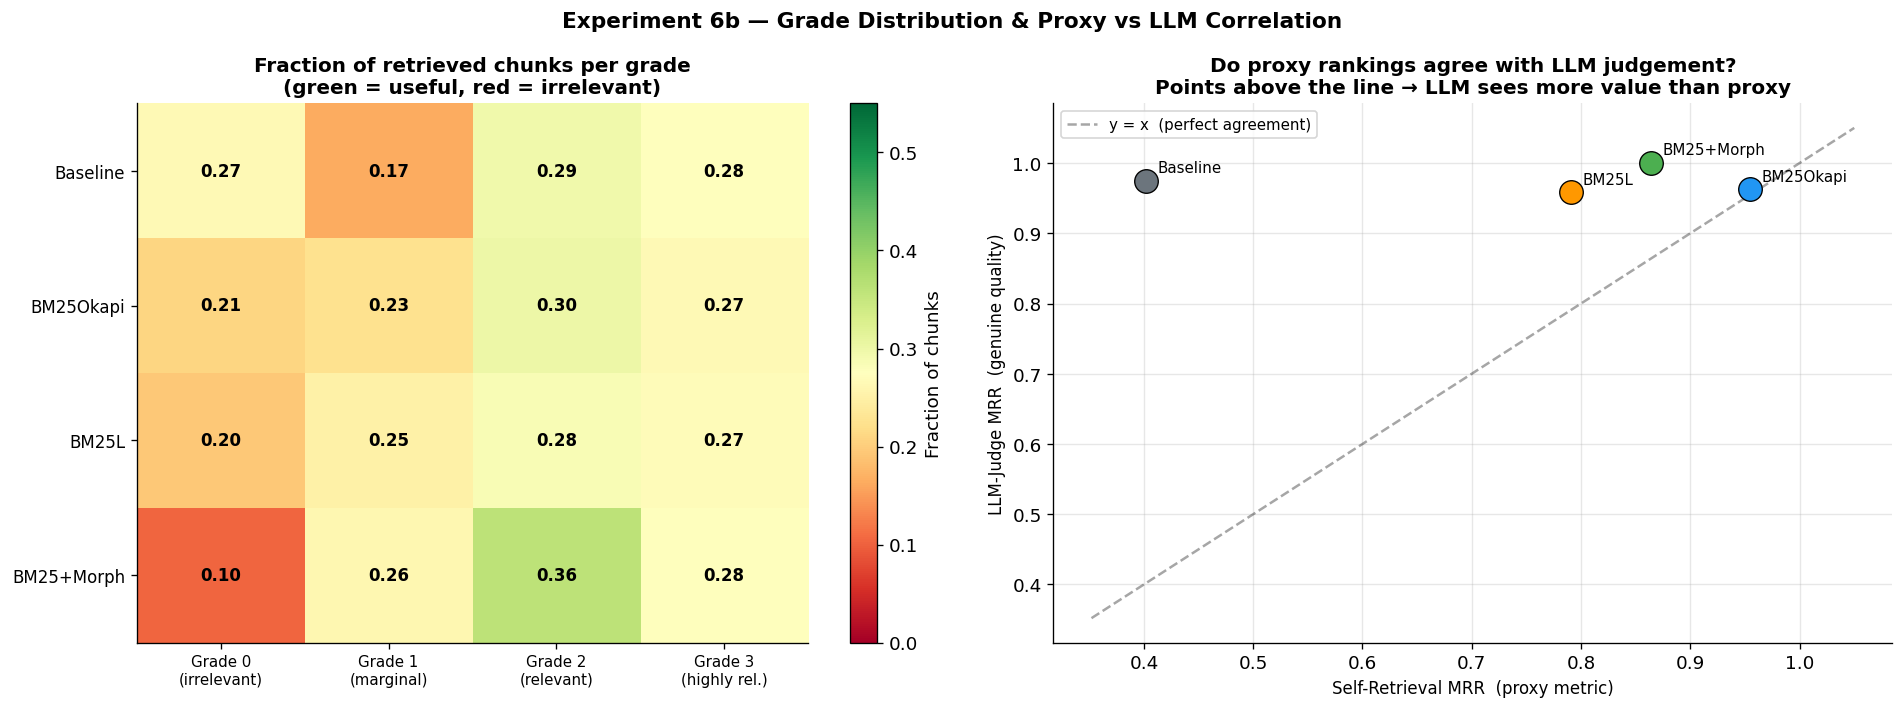

Saved: benchmark_08_grade_correlation.png


In [7]:
if HAS_JUDGE and df_judge is not None and judge_grade_dist:
    _present = [n for n in ALGO_NAMES if n in judge_grade_dist]
    _grade_labels = [
        'Grade 0\n(irrelevant)', 'Grade 1\n(marginal)',
        'Grade 2\n(relevant)',   'Grade 3\n(highly rel.)'
    ]
    _dist_df = pd.DataFrame(
        {n: judge_grade_dist[n] for n in _present},
        index=_grade_labels
    ).T

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, max(4, len(_present) + 2)))
    fig.suptitle('Experiment 6b — Grade Distribution & Proxy vs LLM Correlation',
                 fontsize=13, fontweight='bold')

    # ── Heatmap ────────────────────────────────────────────────────────────
    _cmap = plt.get_cmap('RdYlGn')
    im = ax1.imshow(_dist_df.values, cmap=_cmap, aspect='auto', vmin=0, vmax=0.55)
    ax1.set_xticks(range(4))
    ax1.set_xticklabels(_grade_labels, fontsize=9)
    ax1.set_yticks(range(len(_present)))
    ax1.set_yticklabels([n.replace(' (current)', '') for n in _present], fontsize=10)
    ax1.set_title('Fraction of retrieved chunks per grade\n(green = useful, red = irrelevant)',
                  fontweight='bold')
    plt.colorbar(im, ax=ax1, label='Fraction of chunks')
    for i in range(len(_present)):
        for j in range(4):
            v = _dist_df.iloc[i, j]
            ax1.text(j, i, f'{v:.2f}', ha='center', va='center',
                     fontsize=10, fontweight='bold',
                     color='black' if v < 0.38 else 'white')

    # ── Scatter: self-retrieval MRR vs LLM-MRR ────────────────────────────
    _both = [n for n in _present if n in df_main.index]
    _sr   = [df_main.loc[n, 'MRR'] for n in _both]
    _llm  = [df_judge.loc[n, 'LLM-MRR'] for n in _both]

    for n, x, y in zip(_both, _sr, _llm):
        ax2.scatter(x, y, s=200, color=COLORS.get(n, '#888'),
                    edgecolors='black', linewidth=0.8, zorder=5)
        ax2.annotate(n.replace(' (current)', ''), (x, y),
                     xytext=(7, 5), textcoords='offset points', fontsize=9)

    _lo = min(min(_sr), min(_llm)) - 0.05
    _hi = max(max(_sr), max(_llm)) + 0.05
    ax2.plot([_lo, _hi], [_lo, _hi], 'k--', alpha=0.35, label='y = x  (perfect agreement)')
    ax2.set_xlabel('Self-Retrieval MRR  (proxy metric)', fontsize=10)
    ax2.set_ylabel('LLM-Judge MRR  (genuine quality)', fontsize=10)
    ax2.set_title('Do proxy rankings agree with LLM judgement?\n'
                  'Points above the line → LLM sees more value than proxy',
                  fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.yaxis.grid(True, alpha=0.3)
    ax2.xaxis.grid(True, alpha=0.3)
    ax2.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig('benchmark_08_grade_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: benchmark_08_grade_correlation.png')

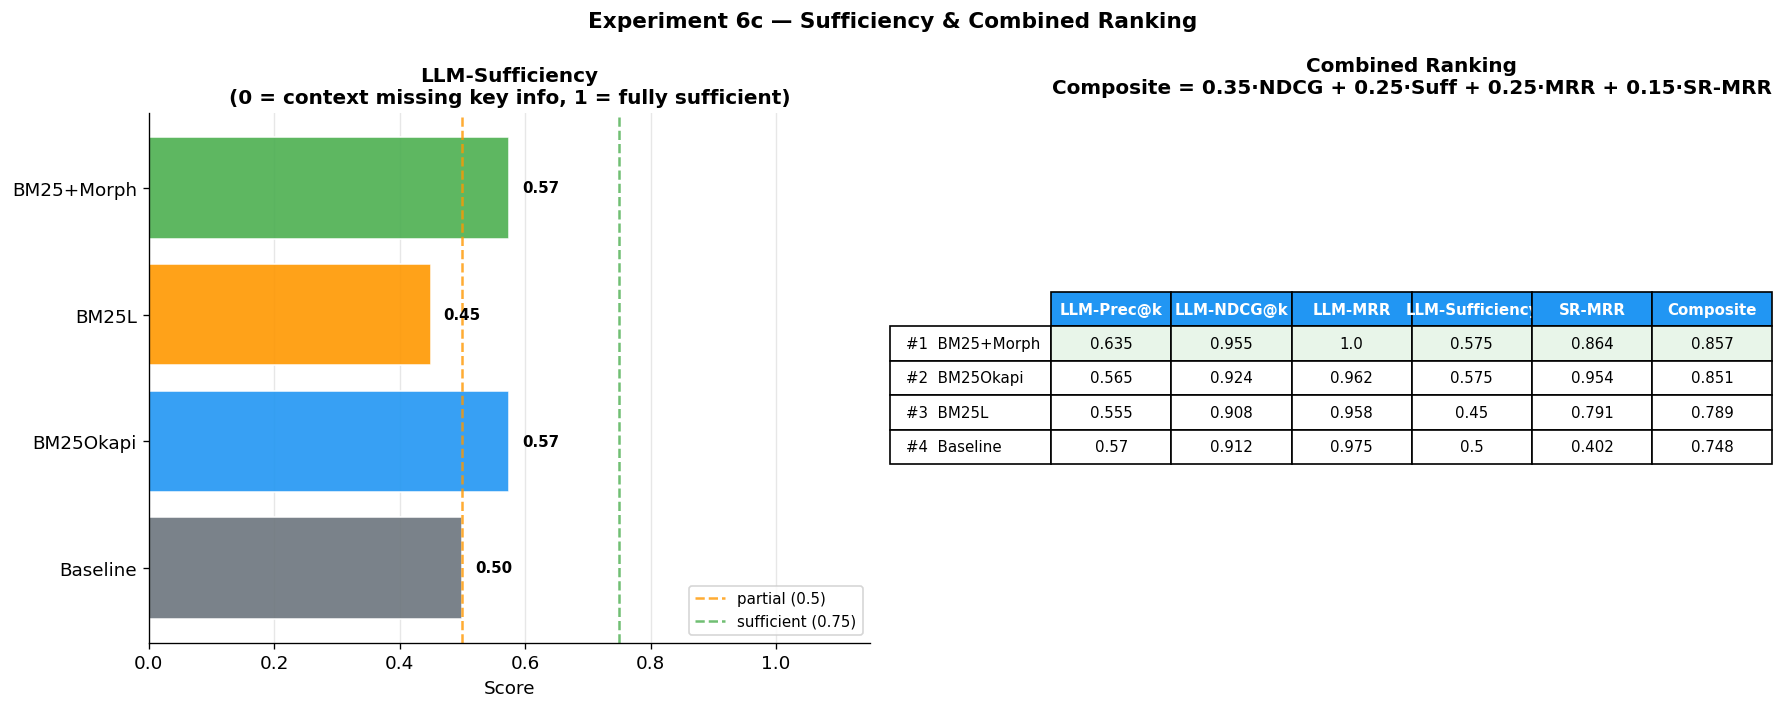

Saved: benchmark_09_sufficiency_ranking.png

=== Composite Ranking ===
  #1 BM25+Morph                    Composite=0.857  NDCG=0.955  Suff=0.575  MRR=1.000
  #2 BM25Okapi                     Composite=0.851  NDCG=0.924  Suff=0.575  MRR=0.963
  #3 BM25L                         Composite=0.789  NDCG=0.908  Suff=0.450  MRR=0.958
  #4 Baseline (current)            Composite=0.748  NDCG=0.912  Suff=0.500  MRR=0.975


In [8]:
if HAS_JUDGE and df_judge is not None:
    _present = [n for n in ALGO_NAMES if n in df_judge.index]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, max(4, len(_present) + 2)))
    fig.suptitle('Experiment 6c — Sufficiency & Combined Ranking',
                 fontsize=13, fontweight='bold')

    # ── Horizontal sufficiency bar ─────────────────────────────────────────
    _suff_vals = [df_judge.loc[n, 'LLM-Sufficiency'] for n in _present]
    _labels    = [n.replace(' (current)', '') for n in _present]
    _clrs      = [COLORS.get(n, '#888') for n in _present]
    bars = ax1.barh(_labels, _suff_vals, color=_clrs, edgecolor='white', alpha=0.9)
    ax1.set_xlim(0, 1.15)
    ax1.axvline(0.50, color='#FF9800', linestyle='--', alpha=0.8, label='partial (0.5)')
    ax1.axvline(0.75, color='#4CAF50', linestyle='--', alpha=0.8, label='sufficient (0.75)')
    ax1.set_title('LLM-Sufficiency\n(0 = context missing key info, 1 = fully sufficient)',
                  fontweight='bold')
    ax1.set_xlabel('Score')
    ax1.legend(fontsize=9, loc='lower right')
    ax1.xaxis.grid(True, alpha=0.3)
    ax1.set_axisbelow(True)
    for bar, val in zip(bars, _suff_vals):
        ax1.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}', va='center', fontsize=9, fontweight='bold')

    # ── Composite ranking table ────────────────────────────────────────────
    _rank_df = df_judge[['LLM-Prec@k', 'LLM-NDCG@k', 'LLM-MRR', 'LLM-Sufficiency']].copy()
    _rank_df['SR-MRR'] = [
        df_main.loc[n, 'MRR'] if n in df_main.index else 0.0
        for n in _rank_df.index
    ]
    _rank_df['Composite'] = (
        _rank_df['LLM-NDCG@k']      * 0.35 +
        _rank_df['LLM-Sufficiency'] * 0.25 +
        _rank_df['LLM-MRR']         * 0.25 +
        _rank_df['SR-MRR']          * 0.15
    )
    _rank_df = _rank_df.sort_values('Composite', ascending=False)

    ax2.axis('off')
    _tbl = ax2.table(
        cellText=_rank_df.round(3).values,
        rowLabels=['#{}  {}'.format(i+1, n.replace(' (current)', ''))
                   for i, n in enumerate(_rank_df.index)],
        colLabels=list(_rank_df.columns),
        cellLoc='center', loc='center'
    )
    _tbl.auto_set_font_size(False)
    _tbl.set_fontsize(9)
    _tbl.scale(1.0, 1.8)
    for j in range(len(_rank_df.columns)):
        _tbl[0, j].set_facecolor('#2196F3')
        _tbl[0, j].set_text_props(color='white', fontweight='bold')
    for j in range(len(_rank_df.columns)):
        _tbl[1, j].set_facecolor('#E8F5E9')  # highlight #1 row
    ax2.set_title('Combined Ranking\nComposite = 0.35·NDCG + 0.25·Suff + 0.25·MRR + 0.15·SR-MRR',
                  fontweight='bold', pad=12)

    plt.tight_layout()
    plt.savefig('benchmark_09_sufficiency_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: benchmark_09_sufficiency_ranking.png')

    print('\n=== Composite Ranking ===')
    for rank, (algo, row) in enumerate(_rank_df.iterrows(), 1):
        print(f'  #{rank} {algo:<28}  Composite={row["Composite"]:.3f}  '
              f'NDCG={row["LLM-NDCG@k"]:.3f}  Suff={row["LLM-Sufficiency"]:.3f}  '
              f'MRR={row["LLM-MRR"]:.3f}')

## Summary & Recommendations

**Decision guide based on Experiment 1:**

| Condition | Action |
|---|---|
| BM25Okapi MRR ≥ Baseline + 0.05 | Integrate BM25Okapi into `bot/rag/search.py` (`uv add rank-bm25`) |
| BM25+Morph MRR ≥ BM25Okapi + 0.03 | Use BM25+Morph (`uv add pymorphy3`); lemmatise corpus on first call |
| All gains < 0.03 | Keep Baseline; invest in better Qdrant index coverage instead |

**Why MRR matters more than Hit@1 here:**  
The fallback feeds a re-ranker (`_rerank_chunks`). A chunk ranked 3rd is still used.
MRR captures this — it rewards algorithms that rank the right chunk higher, not just first.

**Why BM25+Morph is underestimated in this benchmark:**  
Synthetic queries are built from the same word forms found in the chunk.  
Real student queries use different cases — "алгоритм" query matches a chunk containing "алгоритмов"  
only if lemmatisation is applied. Run this notebook on real user queries for a fairer comparison.

**Implementation effort:**
```python
# bot/rag/search.py — replace _fallback_pdf_search_records with BM25Okapi
# ~20 lines + uv add rank-bm25
```
The BM25 index is built once when the first fallback query arrives (lazy init, cached in memory),  
so there is **no startup cost** and no disk serialisation needed.


-
-
-


#
#
#
 
E
x
p
e
r
i
m
e
n
t
 
6
 
—
 
L
L
M
-
a
s
-
J
u
d
g
e
 
a
d
d
i
t
i
o
n
s


|
 
C
h
a
r
t
 
|
 
F
i
l
e
 
|

|
-
-
-
|
-
-
-
|

|
 
L
L
M
 
m
e
t
r
i
c
s
 
b
a
r
 
c
h
a
r
t
 
(
P
r
e
c
,
 
N
D
C
G
,
 
M
R
R
,
 
S
u
f
f
i
c
i
e
n
c
y
)
 
|
 
`
b
e
n
c
h
m
a
r
k
_
0
7
_
l
l
m
_
m
e
t
r
i
c
s
.
p
n
g
`
 
|

|
 
G
r
a
d
e
 
h
e
a
t
m
a
p
 
+
 
p
r
o
x
y
 
v
s
 
L
L
M
 
M
R
R
 
s
c
a
t
t
e
r
 
|
 
`
b
e
n
c
h
m
a
r
k
_
0
8
_
g
r
a
d
e
_
c
o
r
r
e
l
a
t
i
o
n
.
p
n
g
`
 
|

|
 
S
u
f
f
i
c
i
e
n
c
y
 
b
a
r
s
 
+
 
c
o
m
p
o
s
i
t
e
 
r
a
n
k
i
n
g
 
t
a
b
l
e
 
|
 
`
b
e
n
c
h
m
a
r
k
_
0
9
_
s
u
f
f
i
c
i
e
n
c
y
_
r
a
n
k
i
n
g
.
p
n
g
`
 
|


*
*
H
o
w
 
t
o
 
i
n
t
e
r
p
r
e
t
 
t
h
e
 
c
o
m
p
o
s
i
t
e
 
s
c
o
r
e
:
*
*

`
`
`

C
o
m
p
o
s
i
t
e
 
=
 
0
.
3
5
 
×
 
L
L
M
-
N
D
C
G
 
 
+
 
 
0
.
2
5
 
×
 
L
L
M
-
S
u
f
f
i
c
i
e
n
c
y

 
 
 
 
 
 
 
 
 
 
+
 
0
.
2
5
 
×
 
L
L
M
-
M
R
R
 
 
 
+
 
 
0
.
1
5
 
×
 
S
e
l
f
-
R
e
t
r
i
e
v
a
l
 
M
R
R

`
`
`

L
L
M
-
N
D
C
G
 
h
a
s
 
t
h
e
 
h
i
g
h
e
s
t
 
w
e
i
g
h
t
:
 
i
t
 
c
o
m
b
i
n
e
s
 
*
h
o
w
 
g
o
o
d
*
 
(
g
r
a
d
e
)
 
a
n
d
 
*
w
h
e
r
e
*
 
(
r
a
n
k
)
 
t
h
e
 
r
e
l
e
v
a
n
t

c
h
u
n
k
s
 
a
p
p
e
a
r
 
—
 
t
h
e
 
b
e
s
t
 
s
i
n
g
l
e
 
m
e
t
r
i
c
 
f
o
r
 
a
 
c
o
n
t
e
x
t
-
f
e
d
 
a
n
s
w
e
r
 
s
y
s
t
e
m
.


*
*
W
h
e
n
 
s
e
l
f
-
r
e
t
r
i
e
v
a
l
 
a
n
d
 
L
L
M
-
j
u
d
g
e
 
d
i
s
a
g
r
e
e
:
*
*
 
 

I
f
 
a
n
 
a
l
g
o
r
i
t
h
m
 
r
a
n
k
s
 
h
i
g
h
 
o
n
 
S
R
-
M
R
R
 
b
u
t
 
l
o
w
 
o
n
 
L
L
M
-
M
R
R
,
 
i
t
 
r
e
t
r
i
e
v
e
s
 
t
h
e
 
*
e
x
a
c
t
 
s
o
u
r
c
e
 
c
h
u
n
k
*

b
u
t
 
n
o
t
 
n
e
c
e
s
s
a
r
i
l
y
 
c
h
u
n
k
s
 
t
h
a
t
 
*
a
c
t
u
a
l
l
y
 
a
n
s
w
e
r
 
t
h
e
 
q
u
e
s
t
i
o
n
*
.
 
T
r
u
s
t
 
t
h
e
 
L
L
M
-
j
u
d
g
e
 
r
a
n
k
i
n
g
.